### MNIST Digits Classification with Machine Learning
MNIST digits dataset is a vast collection of handwritten digits. This dataset is used for training image processing systems. It is also a very popular dataset used in universities to explain the concepts of classification in machine learning. It contains 60,000 training images and 10,000 testing images

Gerekli kütüphaneler yüklenmesi 

In [12]:
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

mnist = fetch_openml("mnist_784", version=1)

x = mnist.data
y = mnist.target.astype(int)


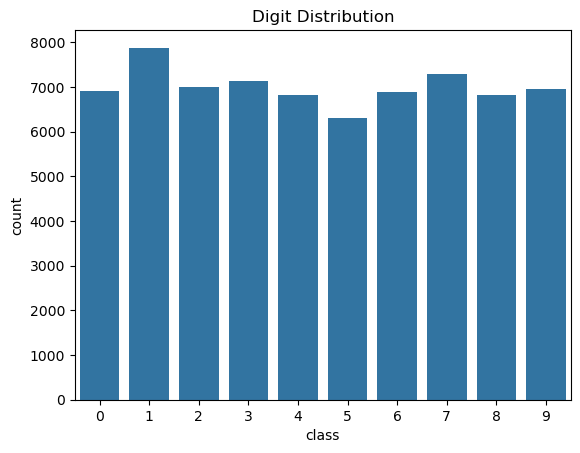

In [13]:
sns.countplot(x=y)
plt.title("Digit Distribution")
plt.show()


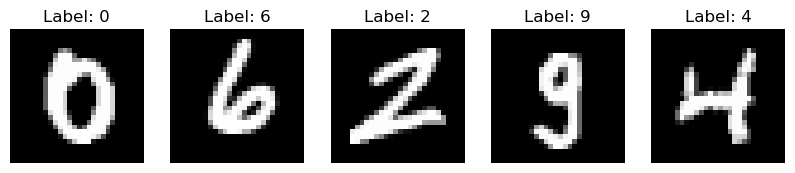

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))

for ax in axes:
    idx = np.random.randint(0, len(x))
    ax.imshow(x.iloc[idx].values.reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {y.iloc[idx]}")
    ax.axis("off")

plt.show()


eda yapıldıktan sonra model train_test_split ile ayırıyoruz ve logisticregresyon modeli ile classification yapmamız lazım 


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
model=LogisticRegression(max_iter=3000)

In [21]:
model.fit(x_train,y_train)

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=3000)

In [23]:
y_pred=model.predict(x_test)

In [24]:
from sklearn.metrics import accuracy_score

In [25]:
acc=accuracy_score(y_test,y_pred)

In [26]:
acc

0.9143571428571429

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
cm=confusion_matrix(y_test,y_pred)

In [29]:
cm

array([[1283,    1,    8,    1,    1,   13,   22,    4,    8,    2],
       [   0, 1552,    7,   11,    3,    6,    0,    4,   15,    2],
       [   8,   13, 1225,   22,   15,   11,   22,   18,   35,   11],
       [   7,   11,   34, 1286,    1,   30,    8,   17,   22,   17],
       [   7,    3,   10,    4, 1183,    5,   13,    9,   11,   50],
       [  13,    9,    6,   49,   13, 1097,   23,    1,   47,   15],
       [   6,    3,   24,    2,   16,   17, 1322,    1,    5,    0],
       [   4,    5,   24,    7,   10,    6,    0, 1402,    1,   44],
       [  11,   26,   18,   39,    6,   42,   11,   10, 1174,   20],
       [   6,    8,    6,   14,   39,    6,    0,   51,   13, 1277]])

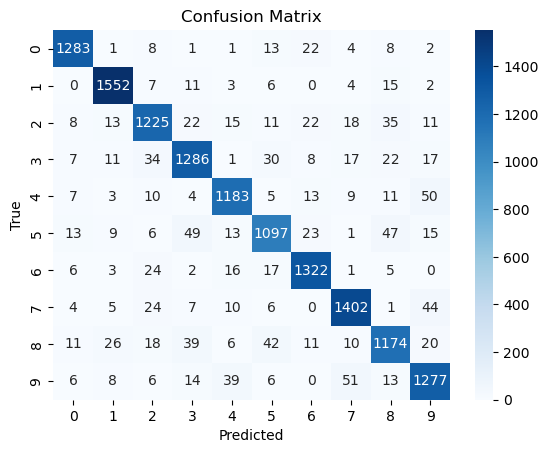

In [30]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [33]:
import joblib

joblib.dump(model, "mnist_model.joblib")




['mnist_model.joblib']

In [48]:
sample = x_test.iloc[0].values.reshape(1, -1)
pred = model.predict(sample)

print("Tahmin:", pred[0])
print("Gerçek:", y_test.iloc[0])

Tahmin: 8
Gerçek: 8


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


https://amanxai.com/2022/05/17/mnist-digits-classification-with-machine-learning/